### Penguins Data:

#### Data Dictionary:

    * species: penguin species (Chinstrap, Adélie, or Gentoo)
    * culmen_length_mm: culmen length (mm)
    * culmen_depth_mm: culmen depth (mm)
    * flipper_length_mm: flipper length (mm)
    * body_mass_g: body mass (g)
    * island: island name (Dream, Torgersen, or Biscoe) in the Palmer Archipelago (Antarctica)
    * sex: penguin sex

#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.pipeline import Pipeline

#### 2) Loading Data:

In [2]:
df = pd.read_csv('penguins_size.csv')

In [3]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [4]:
df.shape

(344, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [6]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


- There are Both Numeric and Categoric Features.
- There are some missing values in Dataset too, which we have to take care of.

#### 3) Data Cleaning and Transformations:

##### 1) Handling Missing Values:

In [7]:
df.isna().sum() / len(df) * 100

species              0.000000
island               0.000000
culmen_length_mm     0.581395
culmen_depth_mm      0.581395
flipper_length_mm    0.581395
body_mass_g          0.581395
sex                  2.906977
dtype: float64

- There are less than 3% of Missing Values overall.
- We can either Impute them or for simplicity, remove them.

In [8]:
df.dropna(inplace= True)

In [9]:
df.isna().sum() / len(df) * 100

species              0.0
island               0.0
culmen_length_mm     0.0
culmen_depth_mm      0.0
flipper_length_mm    0.0
body_mass_g          0.0
sex                  0.0
dtype: float64

##### 2) Species (Target Variable):

In [10]:
df['species'].value_counts()

species
Adelie       146
Gentoo       120
Chinstrap     68
Name: count, dtype: int64

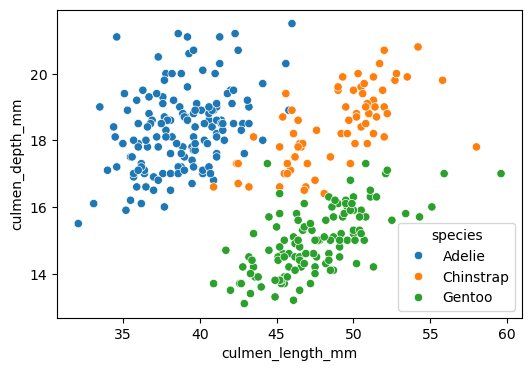

In [11]:
plt.figure(figsize= (6,4))
sns.scatterplot(data= df, x= 'culmen_length_mm', y= 'culmen_depth_mm', hue= 'species')
plt.show()

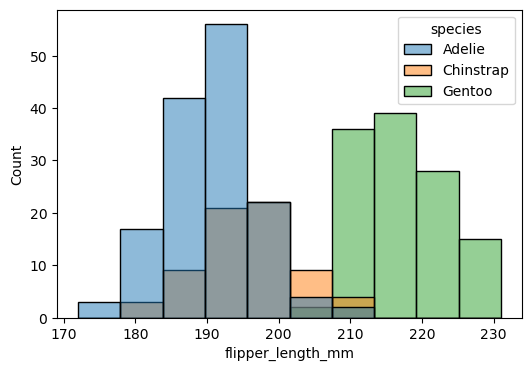

In [12]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'flipper_length_mm', hue= 'species')
plt.show()

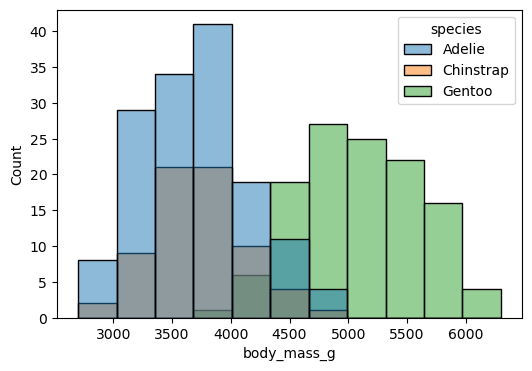

In [13]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'body_mass_g', hue= 'species')
plt.show()

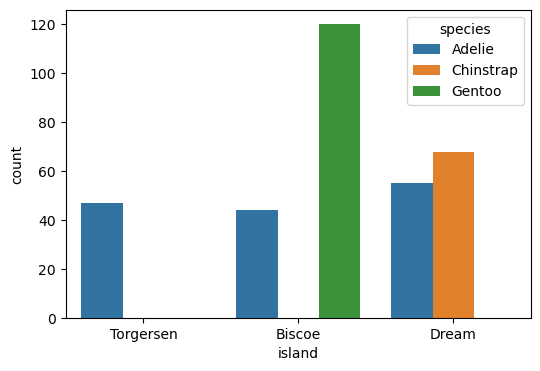

In [14]:
plt.figure(figsize= (6,4))
sns.countplot(data= df, x= 'island', hue= 'species')
plt.show()

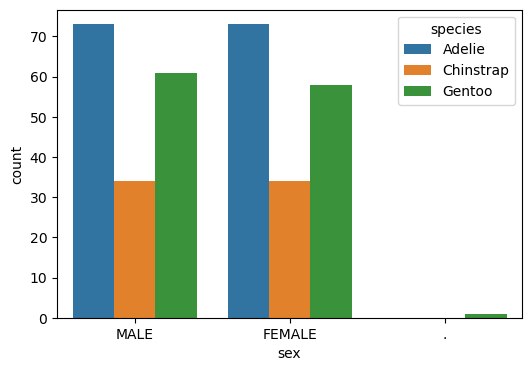

In [15]:
plt.figure(figsize= (6,4))
sns.countplot(data= df, x= 'sex', hue= 'species')
plt.show()

In [16]:
df['sex'].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

##### 3) Island:

In [17]:
df['island'].value_counts()

island
Biscoe       164
Dream        123
Torgersen     47
Name: count, dtype: int64

- This is a Nominal Categorical Feature.
- One hot encoding is needed before passing this feature to model.

In [18]:
island_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 4) culmen_length_mm:

In [19]:
df['culmen_length_mm']

0      39.1
1      39.5
2      40.3
4      36.7
5      39.3
       ... 
338    47.2
340    46.8
341    50.4
342    45.2
343    49.9
Name: culmen_length_mm, Length: 334, dtype: float64

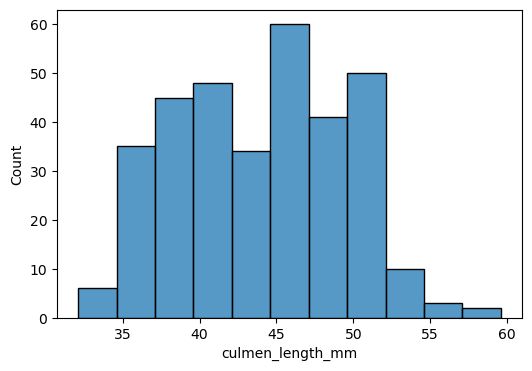

In [20]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'culmen_length_mm')
plt.show()

- Distribution of 'culmen_length_mm' is Normal enough.
- Just Scaling is needed as preprocessing.

In [21]:
cullen_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

##### 5) culmen_depth_mm:

In [22]:
df['culmen_depth_mm']

0      18.7
1      17.4
2      18.0
4      19.3
5      20.6
       ... 
338    13.7
340    14.3
341    15.7
342    14.8
343    16.1
Name: culmen_depth_mm, Length: 334, dtype: float64

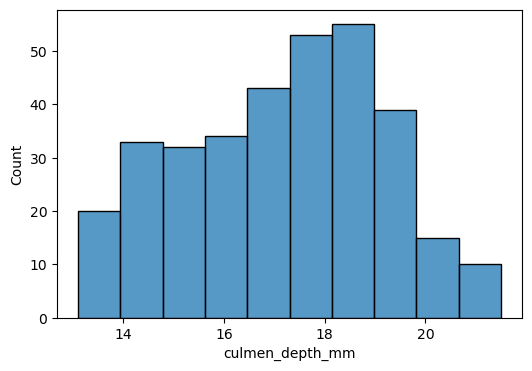

In [23]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'culmen_depth_mm')
plt.show()

- Distribution of 'culmen_depth_mm' is Normal Enough.
- Just scaling is needed for preprocessing.

In [24]:
culdep_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

##### 6) flipper_length_mm:

In [25]:
df['flipper_length_mm']

0      181.0
1      186.0
2      195.0
4      193.0
5      190.0
       ...  
338    214.0
340    215.0
341    222.0
342    212.0
343    213.0
Name: flipper_length_mm, Length: 334, dtype: float64

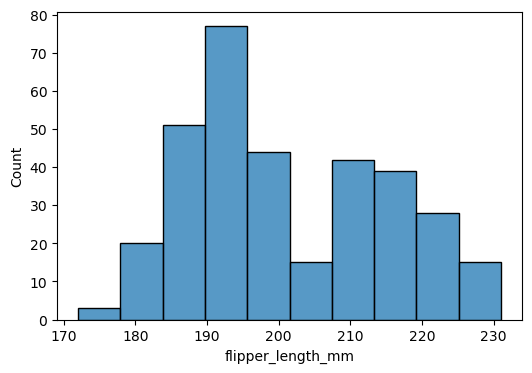

In [26]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'flipper_length_mm')
plt.show()

- Distribution of 'flipper_length_mm' is Normal Enough.
- Just Scaling is needed.

In [27]:
fliplen_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

##### 7) body_mass_g:

In [28]:
df['body_mass_g']

0      3750.0
1      3800.0
2      3250.0
4      3450.0
5      3650.0
        ...  
338    4925.0
340    4850.0
341    5750.0
342    5200.0
343    5400.0
Name: body_mass_g, Length: 334, dtype: float64

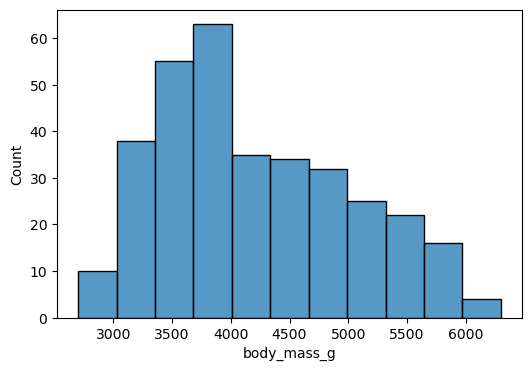

In [29]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'body_mass_g')
plt.show()

- Just Scaling is needed here for preprocessing.

In [30]:
bodym_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

##### 8) Sex:

In [31]:
df['sex'].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

- As we can see, one of the Record here has 'sex' feature wrongly saved as '.'.
- We will look at other features to decide with what to replace that.

In [32]:
df[df['sex'] == '.']

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,.


- This record belongs to Species named 'Gentoo'.

In [33]:
# Checking Mean Values of Features for "MALE" and "FEMALE" penguins for "GEN":

df[df['species'] == 'Gentoo'].groupby('sex').describe().T

sex                           .       FEMALE         MALE
culmen_length_mm  count     1.0    58.000000    61.000000
                  mean     44.5    45.563793    49.473770
                  std       NaN     2.051247     2.720594
                  min      44.5    40.900000    44.400000
                  25%      44.5    43.850000    48.100000
                  50%      44.5    45.500000    49.500000
                  75%      44.5    46.875000    50.500000
                  max      44.5    50.500000    59.600000
culmen_depth_mm   count     1.0    58.000000    61.000000
                  mean     15.7    14.237931    15.718033
                  std       NaN     0.540249     0.741060
                  min      15.7    13.100000    14.100000
                  25%      15.7    13.800000    15.200000
                  50%      15.7    14.250000    15.700000
                  75%      15.7    14.600000    16.100000
                  max      15.7    15.500000    17.300000
flipper_length_mm count     1.0    58.000000    61.000000
                  mean    217.0   212.706897   221.540984
                  std       NaN     3.897856     5.673252
                  min     217.0   203.000000   208.000000
                  25%     217.0   210.000000   218.000000
                  50%     217.0   212.000000   221.000000
                  75%     217.0   215.000000   225.000000
                  max     217.0   222.000000   231.000000
body_mass_g       count     1.0    58.000000    61.000000
                  mean   4875.0  4679.741379  5484.836066
                  std       NaN   281.578294   313.158596
                  min    4875.0  3950.000000  4750.000000
                  25%    4875.0  4462.500000  5300.000000
                  50%    4875.0  4700.000000  5500.000000
                  75%    4875.0  4875.000000  5700.000000
                  max    4875.0  5200.000000  6300.000000

- By Looking at Mean values for All Features, Our Observation Seems More Close to "FEMALE".

In [34]:
df.at[336, 'sex'] = 'FEMALE'

In [35]:
df['sex'].value_counts()

sex
MALE      168
FEMALE    166
Name: count, dtype: int64

- As 'sex' is Nominal Categorical feature, we will use One Hot Encoding to Encode it.

In [36]:
sex_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

#### 4) Final Column Transformer:

In [37]:
preprocessor = ColumnTransformer([
    ('Island', island_pipeline, ['island']),
    ('Culmen_Length', cullen_pipeline, ['culmen_length_mm']),
    ('Culmen_Depth', culdep_pipeline, ['culmen_depth_mm']),
    ('Flipper_Lenght', fliplen_pipeline, ['flipper_length_mm']),
    ('Body_Mass', bodym_pipeline, ['body_mass_g']),
    ('Sex', sex_pipeline, ['sex'])
])

#### 5) Train Test Split:

In [38]:
X = df.drop('species', axis= 1) # Features
y = df['species'] # Target

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [40]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(267, 6)
(67, 6)
(267,)
(67,)


#### 6) Desision Tree Model with Default Parameters:

In [41]:
model_df = Pipeline([
    ('Preprocessing', preprocessor),
    ('Model', DecisionTreeClassifier())
])

In [42]:
model_df.fit(X_train, y_train) #Model Fitting

,steps,"[('Preprocessing', ...), ('Model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Island', ...), ('Culmen_Length', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
y_pred = model_df.predict(X_test) #Predictions Using Model

In [44]:
y_pred

array(['Adelie', 'Gentoo', 'Adelie', 'Chinstrap', 'Adelie', 'Gentoo',
       'Gentoo', 'Chinstrap', 'Chinstrap', 'Chinstrap', 'Adelie',
       'Adelie', 'Gentoo', 'Adelie', 'Gentoo', 'Adelie', 'Adelie',
       'Chinstrap', 'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Gentoo',
       'Chinstrap', 'Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Chinstrap',
       'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie', 'Adelie', 'Gentoo',
       'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Chinstrap', 'Chinstrap', 'Adelie', 'Adelie', 'Gentoo',
       'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Gentoo', 'Gentoo',
       'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Chinstrap',
       'Chinstrap', 'Gentoo', 'Gentoo', 'Gentoo', 'Adelie', 'Adelie',
       'Gentoo', 'Adelie'], dtype=object)

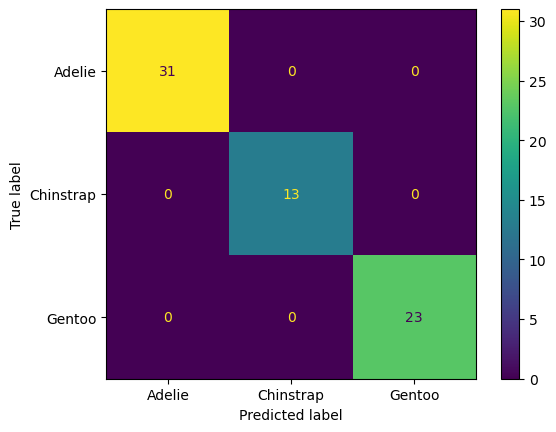

In [45]:
# Confusion Matrix:

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm ,display_labels= model_df.classes_)
disp.plot()
plt.show()

In [46]:
# Classification Report:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        31
   Chinstrap       1.00      1.00      1.00        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



In [61]:
# Feature Importance According To The Model:

pd.DataFrame(index= model_df.named_steps['Preprocessing'].get_feature_names_out(), 
             data= model_df.named_steps['Model'].feature_importances_, 
             columns= ['Feature Importance']).sort_values(by= 'Feature Importance', ascending= False)

,Feature Importance
Flipper_Lenght__flipper_length_mm,0.507703
Culmen_Length__culmen_length_mm,0.351989
Island__island_Biscoe,0.060770
Island__island_Dream,0.033464
Sex__sex_MALE,0.021943
Culmen_Depth__culmen_depth_mm,0.018279
Body_Mass__body_mass_g,0.005851
Island__island_Torgersen,0.000000
Sex__sex_FEMALE,0.000000


- "flipper_length_mm" and "culmen_length_mm" seems to be most important features for model to classify the data.
- As more than 80% of Importance is between only two features, we can probably prune the Tree (Make it less complex) and still get the same accuracy.	

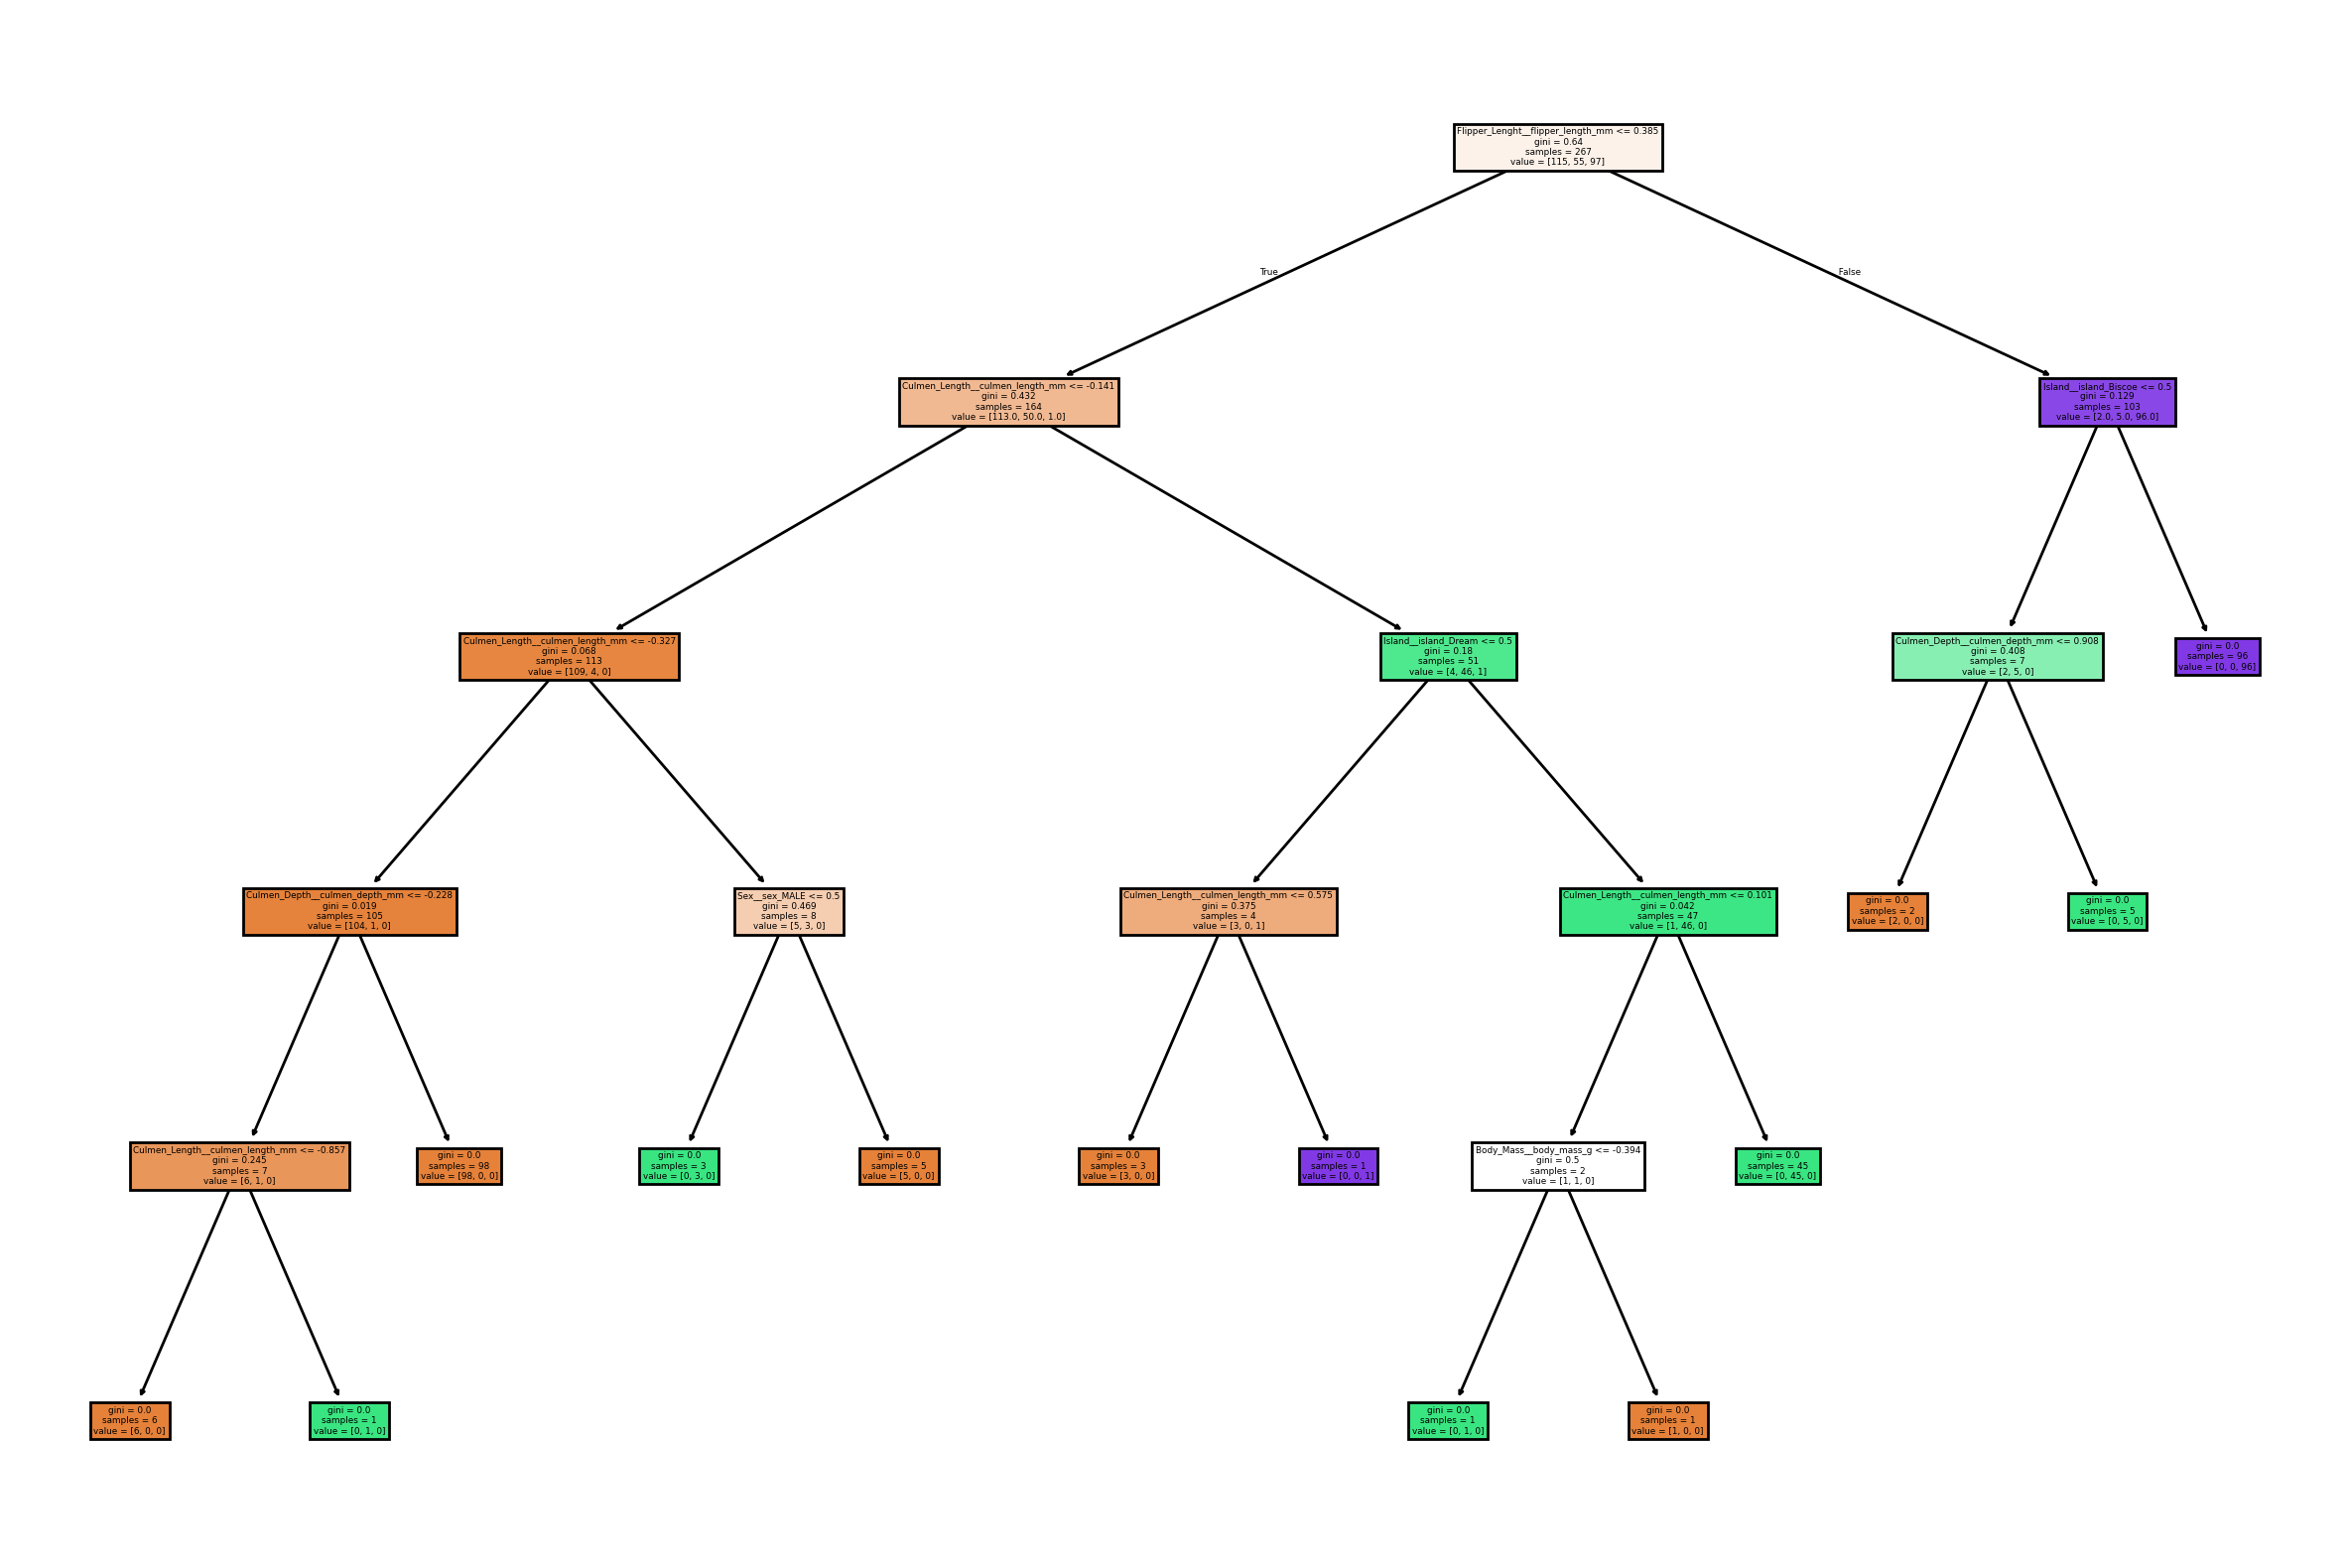

In [63]:
# Plotting The Decision Tree:

plt.figure(figsize= (15, 10), dpi= 200)
plot_tree(model_df.named_steps['Model'], 
          feature_names= model_df.named_steps['Preprocessing'].get_feature_names_out(),
         filled= True)
plt.show()